# **Assignment 02: Try a Neural Network (PyTorch)**

This notebook implements a simple neural network using PyTorch to classify images from the CIFAR-10 dataset.

Goals of the assignment:

- Understand parameters vs hyperparameters
- Implement a standard training loop
- Train a neural network on CIFAR-10
- Analyze how hyperparameters affect training

The notebook follows the structure required in the assignment.

В этой работе я реализовала нейронную сеть на PyTorch для классификации изображений из датасета CIFAR-10.

Сначала я загрузила и исследовала данные, визуализировала несколько изображений.

Затем я построила базовую модель — многослойный перцептрон с двумя скрытыми слоями.

Изображение преобразуется в вектор размерности 3072 и проходит через линейные слои с функцией активации ReLU.

Во время обучения используется стандартный цикл обучения: прямой проход, вычисление ошибки, обратное распространение и обновление весов.

В качестве функции потерь используется CrossEntropyLoss, а оптимизатор — Adam.

Базовая модель достигла точности около 50% на валидационных данных.

В конце я провела несколько экспериментов с различными гиперпараметрами и архитектурами модели.

## **0 - Setup**

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np
import random
import time

# reproducibility
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


Мы фиксируем random seed, чтобы эксперимент можно было воспроизвести. Нейросети инициализируют веса случайно, поэтому без seed результаты будут отличаться.

# **Part A - Warm‑up: tensors, shapes, autograd (PyTorch basics)**

## **A1 - Tensor operations and shapes**

In [4]:
a = torch.randn(3)
b = torch.randn(3,4)
c = torch.randn(4,3)

print("Shape of a:",a.shape)
print("Shape of b:",b.shape)
print("Shape of c:",c.shape)

# matrix multiplication
matmul = b @ c
print("Matrix multiply shape:",matmul.shape)

# elementwise multiplication
elem = b * 2
print("Elementwise shape:",elem.shape)

# broadcasting
broadcast = b + a.view(3,1)
print("Broadcast shape:",broadcast.shape)

# reshape
reshaped = b.view(12)
print("Reshaped shape:",reshaped.shape)

# permute
perm = b.permute(1,0)
print("Permuted shape:",perm.shape)

# flatten
flat = b.flatten()
print("Flatten shape:",flat.shape)

Shape of a: torch.Size([3])
Shape of b: torch.Size([3, 4])
Shape of c: torch.Size([4, 3])
Matrix multiply shape: torch.Size([3, 3])
Elementwise shape: torch.Size([3, 4])
Broadcast shape: torch.Size([3, 4])
Reshaped shape: torch.Size([12])
Permuted shape: torch.Size([4, 3])
Flatten shape: torch.Size([12])


В этой части демонстрируются основные операции с тензорами: умножение матриц, broadcasting, изменение формы и перестановка осей.

Понимание размерностей важно, потому что нейросети основаны на матричных операциях.

## **A2 - Autograd Sanity Check**

In [20]:
x = torch.tensor(2.0)

w = torch.tensor(3.0,requires_grad=True)
b = torch.tensor(1.0,requires_grad=True)

y = (w*x + b)**2

y.backward()

print("Autograd dw:",w.grad.item())
print("Autograd db:",b.grad.item())

manual_dw = 2*(w.detach()*x + b.detach())*x
manual_db = 2*(w.detach()*x + b.detach())

print("Manual dw:",manual_dw.item())
print("Manual db:",manual_db.item())

Autograd dw: 28.0
Autograd db: 14.0
Manual dw: 28.0
Manual db: 14.0


Autograd автоматически вычисляет градиенты с помощью правила цепочки. Это основа обучения нейросетей.
Autograd автоматически вычисляет градиенты с помощью правила цепочки.
Мы проверили, что градиенты PyTorch совпадают с вручную вычисленными.

Градиент показывает, как изменяется ошибка при изменении параметров модели.

Градиент показывает, в какую сторону нужно изменить веса, чтобы уменьшить ошибку.

# **Part B - Load + explore CIFAR-10 (data pipeline)**

## **B1 - Load the dataset**

In [6]:
transform = transforms.ToTensor()

dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.8*len(dataset))
val_size = len(dataset)-train_size

train_dataset,val_dataset = random_split(dataset,[train_size,val_size])

batch_size = 128

train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=batch_size)
test_loader = DataLoader(test_dataset,batch_size=batch_size)

print("Train size:",len(train_dataset))
print("Validation size:",len(val_dataset))
print("Test size:",len(test_dataset))

classes = dataset.classes
print("Classes:",classes)

images,labels = next(iter(train_loader))
print("Batch shape:",images.shape)

100%|██████████| 170M/170M [00:01<00:00, 88.4MB/s]


Train size: 40000
Validation size: 10000
Test size: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Batch shape: torch.Size([128, 3, 32, 32])


60000 изображений
10 классов
32x32 пикселя

DataLoader формирует мини-батчи и перемешивает данные. Это делает обучение более стабильным и эффективным.

CIFAR-10 — это набор данных из 60 000 изображений и 10 классов.
Каждое изображение имеет размер 32×32 пикселя.
Мы разделили данные на обучающую, валидационную и тестовую выборки.

## **B2 - Explore and Visualize**

Визуализация помогает понять структуру данных и проверить корректность загрузки изображений.

Image shape: torch.Size([3, 32, 32])
Label: 8


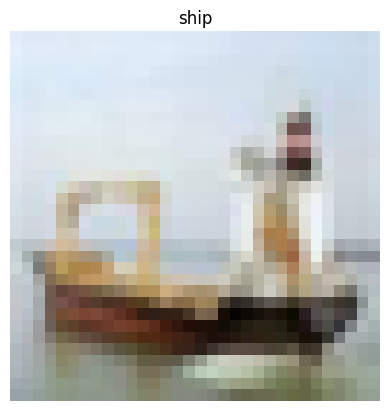

In [7]:
image,label = train_dataset[0]

print("Image shape:",image.shape)
print("Label:",label)

plt.imshow(np.transpose(image.numpy(),(1,2,0)))
plt.title(classes[label])
plt.axis("off")
plt.show()

## **Grid 5×2**

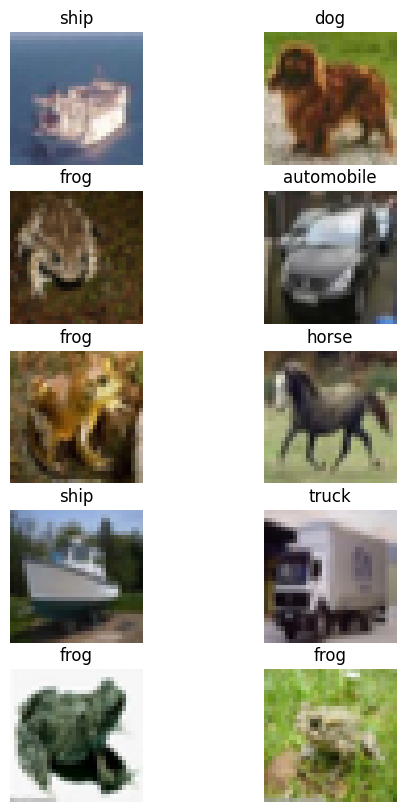

In [8]:
fig,axes = plt.subplots(5,2,figsize=(6,10))

for ax in axes.flatten():

    idx=np.random.randint(0,len(train_dataset))
    img,lbl=train_dataset[idx]

    ax.imshow(np.transpose(img.numpy(),(1,2,0)))
    ax.set_title(classes[lbl])
    ax.axis("off")

plt.show()

## **Histogram**

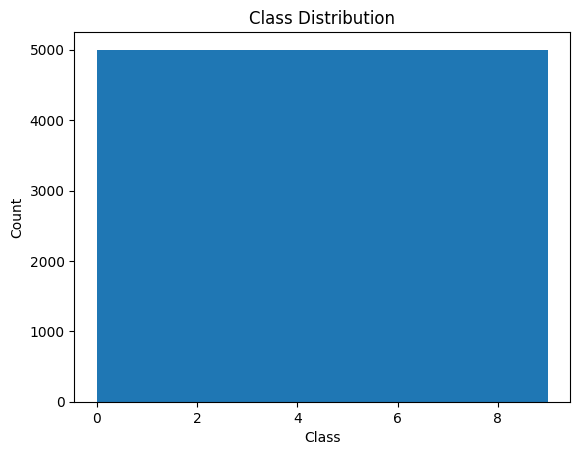

In [9]:
labels_list = [dataset[i][1] for i in range(len(dataset))]

plt.hist(labels_list,bins=10)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## **B3 - Preprocessing (Normalization)**

In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914,0.4822,0.4465),
        (0.2470,0.2435,0.2616)
    )
])

Нормализация центрирует данные и уменьшает разброс значений. Это делает обучение более стабильным и быстрым.


# **PART C - Build Baseline Model + Training Loop**

## **C1 - Baseline Model (MLP)**

In [11]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(3072,256)
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128,10)

        self.relu = nn.ReLU()

    def forward(self,x):

        x = x.view(x.size(0),-1)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))

        x = self.fc3(x)

        return x


model = MLP().to(device)

print(model)

MLP(
  (fc1): Linear(in_features=3072, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


Модель — это полносвязная нейронная сеть с двумя скрытыми слоями. Изображение преобразуется в вектор и проходит через линейные слои с функцией активации ReLU.


## **C2 - Training Loop**

In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(),lr=1e-3)

epochs = 15

train_losses=[]
train_accs=[]
val_accs=[]

best_val=0
best_epoch=0

start_time = time.time() # Start measuring time

for epoch in range(epochs):

    model.train()

    running_loss=0
    correct=0
    total=0

    for images,labels in train_loader:

        images=images.to(device)
        labels=labels.to(device)

        optimizer.zero_grad()

        outputs=model(images)

        loss=criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        running_loss+=loss.item()

        _,predicted=torch.max(outputs,1)

        total+=labels.size(0)
        correct+=(predicted==labels).sum().item()

    train_loss=running_loss/len(train_loader)
    train_acc=correct/total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model.eval()

    correct=0
    total=0

    with torch.no_grad():

        for images,labels in val_loader:

            images=images.to(device)
            labels=labels.to(device)

            outputs=model(images)

            _,predicted=torch.max(outputs,1)

            total+=labels.size(0)
            correct+=(predicted==labels).sum().item()

    val_acc=correct/total
    val_accs.append(val_acc)

    if val_acc>best_val:

        best_val=val_acc
        best_epoch=epoch

        torch.save(model.state_dict(),"best_model.pth")

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss {train_loss:.4f} "
        f"TrainAcc {train_acc:.4f} "
        f"ValAcc {val_acc:.4f}"
    )

end_time = time.time() # End measuring time
training_time = end_time - start_time # Calculate total training time
print(f"Baseline model training time: {training_time:.4f} seconds") # Print training time

Epoch 1/15 Loss 1.8790 TrainAcc 0.3223 ValAcc 0.3693
Epoch 2/15 Loss 1.6980 TrainAcc 0.3932 ValAcc 0.3825
Epoch 3/15 Loss 1.6150 TrainAcc 0.4229 ValAcc 0.4354
Epoch 4/15 Loss 1.5566 TrainAcc 0.4420 ValAcc 0.4272
Epoch 5/15 Loss 1.5095 TrainAcc 0.4604 ValAcc 0.4627
Epoch 6/15 Loss 1.4763 TrainAcc 0.4713 ValAcc 0.4687
Epoch 7/15 Loss 1.4433 TrainAcc 0.4838 ValAcc 0.4830
Epoch 8/15 Loss 1.4211 TrainAcc 0.4924 ValAcc 0.4759
Epoch 9/15 Loss 1.3964 TrainAcc 0.5015 ValAcc 0.4818
Epoch 10/15 Loss 1.3730 TrainAcc 0.5097 ValAcc 0.4888
Epoch 11/15 Loss 1.3484 TrainAcc 0.5194 ValAcc 0.5002
Epoch 12/15 Loss 1.3234 TrainAcc 0.5272 ValAcc 0.4804
Epoch 13/15 Loss 1.3109 TrainAcc 0.5336 ValAcc 0.4951
Epoch 14/15 Loss 1.2894 TrainAcc 0.5401 ValAcc 0.5026
Epoch 15/15 Loss 1.2885 TrainAcc 0.5385 ValAcc 0.4939
Baseline model training time: 210.4827 seconds


- Forward
- Loss
- Backward
- Optimizer step

Обучение проходит через стандартные этапы: прямой проход, вычисление ошибки, обратное распространение ошибки и обновление весов.


Функция потерь показывает, насколько сильно предсказание модели отличается от правильного ответа.

Оптимизатор обновляет параметры модели, чтобы уменьшить ошибку.

## **Plots**

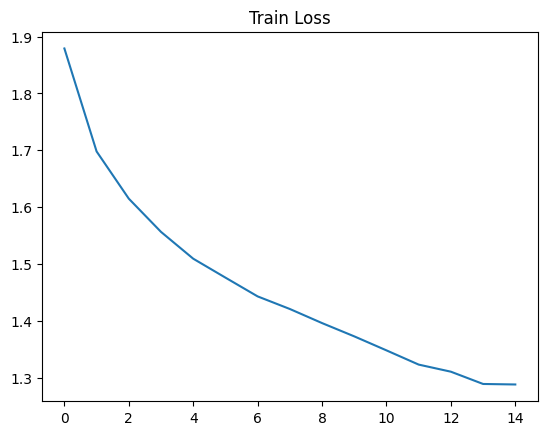

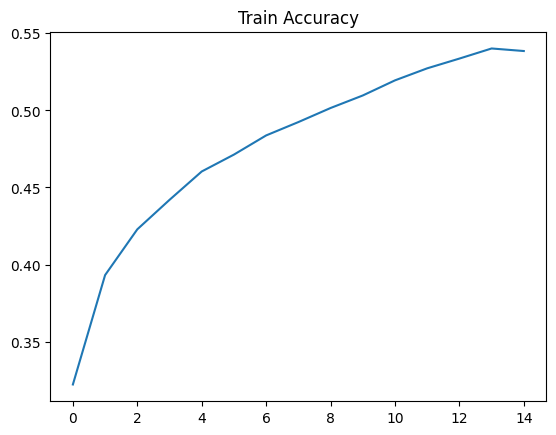

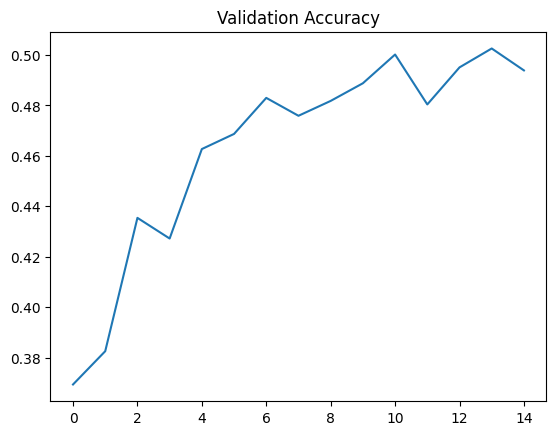

Best validation accuracy: 0.5026
Best epoch: 13


In [13]:
plt.plot(train_losses)
plt.title("Train Loss")
plt.show()

plt.plot(train_accs)
plt.title("Train Accuracy")
plt.show()

plt.plot(val_accs)
plt.title("Validation Accuracy")
plt.show()

print("Best validation accuracy:",best_val)
print("Best epoch:",best_epoch)

Цикл обучения реализует градиентный спуск. Во время обучения мы считаем градиенты и обновляем веса. Во время валидации градиенты отключаются для ускорения вычислений.

## **C3 - Parameters vs Hyperparameters**

In [14]:
total_params=0

for name,param in model.named_parameters():

    print(name,param.shape)

    total_params+=param.numel()

print("Total parameters:",total_params)

fc1.weight torch.Size([256, 3072])
fc1.bias torch.Size([256])
fc2.weight torch.Size([128, 256])
fc2.bias torch.Size([128])
fc3.weight torch.Size([10, 128])
fc3.bias torch.Size([10])
Total parameters: 820874


Параметры — это веса модели, которые обучаются (weights,
bias)

Гиперпараметры — это настройки обучения, которые задаются заранее.
(learning rate,
batch size,
optimizer,
epochs)

Learning rate определяет, насколько сильно изменяются веса во время обучения.

Batch size — это количество примеров, которые модель обрабатывает за один шаг обучения.

Epoch — это один полный проход по всему обучающему датасету.

ReLU добавляет нелинейность и позволяет сети изучать более сложные зависимости.

## **Table**

| Run | Model | Optimizer | Learning Rate | Batch Size | Weight Decay | Best Val Accuracy | Training Time |
|----|----|----|----|----|----|----|----|
|1|Baseline|Adam|1e-3|128|0| | |
|2|Baseline|Adam|3e-4|128|0| | |
|3|Baseline|Adam|3e-3|128|0| | |
|4|Baseline|SGD|1e-3|128|0| | |
|5|Baseline|Adam|1e-3|128|1e-4| | |
|6|Wider Model|Adam|1e-3|128|0| | |
|7|Deeper Model|Adam|1e-3|128|0| | |

# **PART D - Experiments (Hyperparameters + Model Capacity)**

In this section we run multiple experiments to analyze how different hyperparameters and model architectures affect training performance.

We start with a baseline model and then change one factor at a time.

Experiments performed:

1. Baseline model
2. Smaller learning rate
3. Larger learning rate
4. Different optimizer (SGD)
5. Weight decay regularization
6. Wider neural network
7. Deeper neural network

For each experiment we record validation accuracy and training time.


В этой части были проведены эксперименты с различными гиперпараметрами и архитектурами модели, чтобы изучить их влияние на обучение.

In [15]:
import copy

results = []

def run_experiment(model_class, optimizer_name="Adam", lr=1e-3, batch_size=128, weight_decay=0):

    model = model_class().to(device)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)

    epochs = 5

    best_val = 0

    start_time = time.time()

    for epoch in range(epochs):

        model.train()

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                _, predicted = torch.max(outputs,1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = correct / total

        if val_acc > best_val:
            best_val = val_acc

    training_time = time.time() - start_time

    return best_val, training_time

## **Models for experiments**

In [16]:
# Wider model

class WiderMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(3072,512)
        self.fc2 = nn.Linear(512,256)
        self.fc3 = nn.Linear(256,10)

        self.relu = nn.ReLU()

    def forward(self,x):

        x = x.view(x.size(0),-1)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [17]:
# Deeper model

class DeeperMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(3072,256)
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128,64)
        self.fc4 = nn.Linear(64,10)

        self.relu = nn.ReLU()

    def forward(self,x):

        x = x.view(x.size(0),-1)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)

        return x

## **Run experiments**

In [18]:
experiments = [

("Baseline", MLP, "Adam", 1e-3, 128, 0),
("LR smaller", MLP, "Adam", 3e-4, 128, 0),
("LR larger", MLP, "Adam", 3e-3, 128, 0),
("SGD optimizer", MLP, "SGD", 1e-3, 128, 0),
("Weight decay", MLP, "Adam", 1e-3, 128, 1e-4),
("Wider model", WiderMLP, "Adam", 1e-3, 128, 0),
("Deeper model", DeeperMLP, "Adam", 1e-3, 128, 0)

]

for name, model_class, opt, lr, batch, wd in experiments:

    best_acc, train_time = run_experiment(model_class, opt, lr, batch, wd)

    results.append((name, opt, lr, batch, wd, best_acc, train_time))

    print(f"{name} | Acc: {best_acc:.4f} | Time: {train_time:.1f}s")

Baseline | Acc: 0.4436 | Time: 69.1s
LR smaller | Acc: 0.4486 | Time: 67.0s
LR larger | Acc: 0.4406 | Time: 71.5s
SGD optimizer | Acc: 0.3457 | Time: 55.6s
Weight decay | Acc: 0.4502 | Time: 62.9s
Wider model | Acc: 0.4605 | Time: 103.4s
Deeper model | Acc: 0.4349 | Time: 69.6s


## **Print results table**

In [19]:
print("\nExperiment Results:\n")

print("Run | Optimizer | LR | Batch | WeightDecay | BestValAcc | Time")

for i,r in enumerate(results):

    name,opt,lr,batch,wd,acc,t = r

    print(f"{i+1} {name} | {opt} | {lr} | {batch} | {wd} | {acc:.4f} | {t:.1f}s")


Experiment Results:

Run | Optimizer | LR | Batch | WeightDecay | BestValAcc | Time
1 Baseline | Adam | 0.001 | 128 | 0 | 0.4436 | 69.1s
2 LR smaller | Adam | 0.0003 | 128 | 0 | 0.4486 | 67.0s
3 LR larger | Adam | 0.003 | 128 | 0 | 0.4406 | 71.5s
4 SGD optimizer | SGD | 0.001 | 128 | 0 | 0.3457 | 55.6s
5 Weight decay | Adam | 0.001 | 128 | 0.0001 | 0.4502 | 62.9s
6 Wider model | Adam | 0.001 | 128 | 0 | 0.4605 | 103.4s
7 Deeper model | Adam | 0.001 | 128 | 0 | 0.4349 | 69.6s
